<a href="https://colab.research.google.com/github/santiagoramosg/ia/blob/main/M%C3%A9tricas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

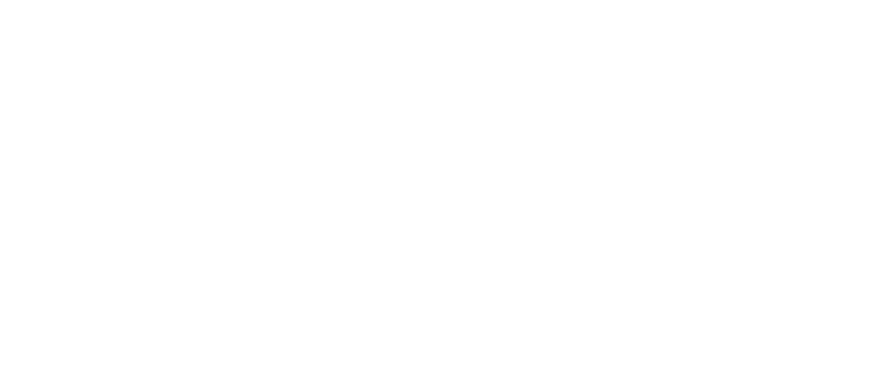

# Taller Introducción a la IA: Métricas Aprendizaje Supervisado


## No olvide escribir su correo y nombre, para la entrega del taller y posterior calificación

In [55]:
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import (
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    silhouette_score,
    precision_recall_curve,
    auc
)
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

## Creamos el dataset

In [56]:
X, y = make_classification(n_samples=1000, n_features=20, n_informative=10, n_classes=2, random_state=42)

In [57]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

## Creamos el modelo

In [58]:
svm_model = SVC(kernel='linear', random_state=42)
svm_model.fit(X_train, y_train)

SVC(kernel='linear', random_state=42)

In [59]:
y_pred = svm_model.predict(X_test)

In [60]:
cm = confusion_matrix(y_test, y_pred)

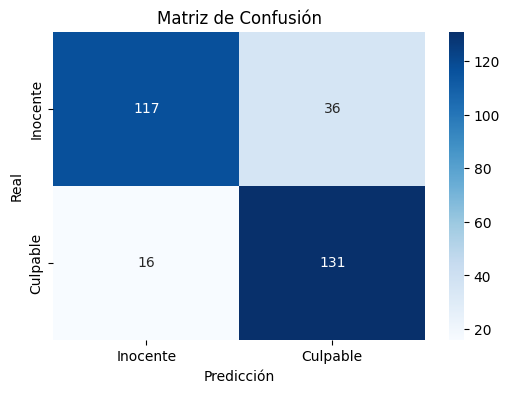

In [61]:
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=["Inocente", "Culpable"], yticklabels=["Inocente", "Culpable"])
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.title('Matriz de Confusión')
plt.show()

In [62]:
VP = cm[0,0]  # Verdaderos Positivos
FN = cm[0,1]  # Falsos Negativos
FP = cm[1,0]  # Falsos Positivos
VN = cm[1,1]  # Verdaderos Negativos

print(f"VP: {VP}")
print(f"FN: {FN}")
print(f"FP: {FP}")
print(f"VN: {VN}")

VP: 117
FN: 36
FP: 16
VN: 131


In [63]:
# Utilizando las variables anteriores:

accuracy = (VP+VN)/(VP+VN+FP+VN)  # Completa la fórmula para la exactitud (accuracy)
precision = VP/(VP+FP)  # Completa la fórmula para la precisión (precision)
recall = VP+(VP+FN) # Completa la fórmula para el recall
f1_score = (precision*recall) + (precision+recall) # Completa la fórmula para el F1-score
fpr=FP/(FP+VN)

In [64]:
print(f"Exactitud (Accuracy): {accuracy:.2f}")
print(f"Precisión (Precision): {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1-Score: {f1_score:.2f}")

Exactitud (Accuracy): 0.63
Precisión (Precision): 0.88
Recall: 270.00
F1-Score: 508.40


In [65]:
"""
Importante tener en cuenta que lo anterior se puede obtener facilmente usando la función classification_report


from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

"""

'\nImportante tener en cuenta que lo anterior se puede obtener facilmente usando la función classification_report\n\n\nfrom sklearn.metrics import classification_report\n\nprint(classification_report(y_test, y_pred))\n\n'

In [66]:
# Obtener puntajes de decisión o probabilidades para la clase positiva
# (completa con decision_function o predict_proba)
y_scores = svm_model.decision_function(X_test)

In [67]:
df_scores = pd.DataFrame(y_scores, columns=["Score"])
print(df_scores.head())

      Score
0  2.062054
1 -4.081137
2 -3.131730
3  0.533541
4 -3.288151


In [68]:
# Calcular los valores de la curva ROC
fpr, tpr, thresholds = roc_curve(y_test,y_pred)

In [69]:
# Calcular el AUC (Área bajo la curva)
auc_score = roc_auc_score(y_test, y_pred)

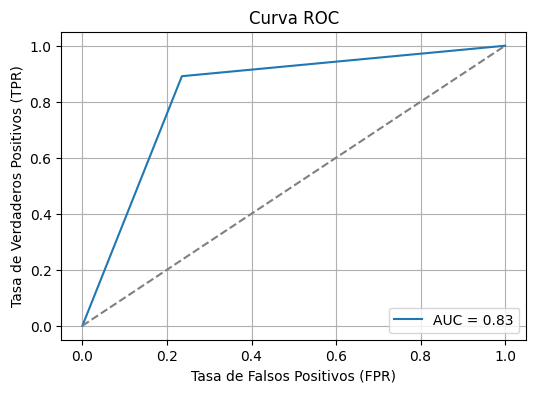

In [70]:
plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, label=f'AUC = {auc_score:.2f}')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title('Curva ROC')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

In [71]:
precision, recall, thresholds_pr = precision_recall_curve(y_test, y_scores)

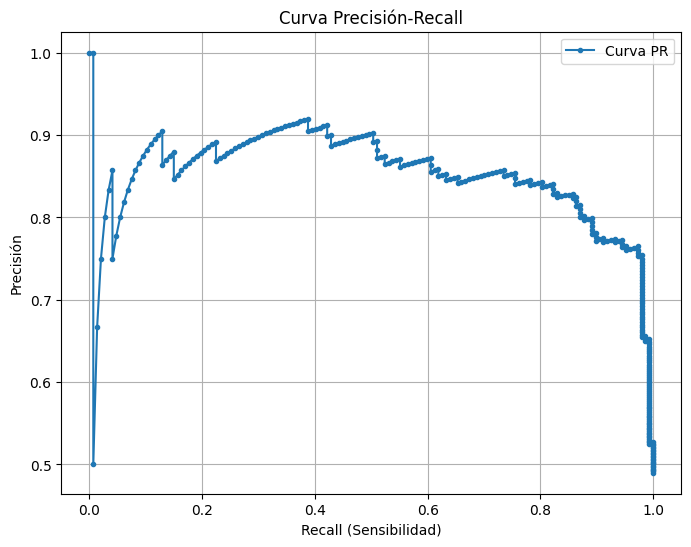

In [72]:
plt.figure(figsize=(8, 6))
plt.plot(recall, precision, marker='.', label='Curva PR')
plt.xlabel('Recall (Sensibilidad)')
plt.ylabel('Precisión')
plt.title('Curva Precisión-Recall')
plt.legend()
plt.grid(True)
plt.show()

In [73]:
auc_pr = auc(recall, precision)
print(f"Área Bajo la Curva PR (AUC-PR): {auc_pr:.4f}")

Área Bajo la Curva PR (AUC-PR): 0.8504


# **PREGUNTAS**




1. **¿Cuál fue el valor del recall?**



2. **¿En qué situación podría ser preferible
tener un modelo con alto recall pero baja precisión en este concurso de detectives? ¿Deberías desconfiar en el modelo a pesar del buen recall? Justifica tu respuesta en el contexto del problema.**

3. **Si el organizador del concurso cambia las reglas para penalizar más los falsos positivos que los falsos negativos, ¿qué métrica deberías optimizar y por qué?**

4. **Si decides comparar varios modelos utilizando la curva ROC y el AUC y la curva PR y , ¿qué representa esta métrica en el contexto del concurso? ¿Por qué podría ser más útil que el accuracy cuando las clases están desbalanceadas (pocos culpables y muchos inocentes en el conjunto de datos)?**

5. **¿Por qué el F1-Score se considera una de las métricas más importantes para evaluar modelos de clasificación?**